# Ejercicio 2

**Consigna:**

a) Elegir algún modelo clásico de clasificación (por ejemplo: random forest o regresión logística). Entrenar y evaluar su performance usando las métricas clásicas (precision, recall, accuracy, f1-score) y crear la matriz de confusión. Interpretar los resultados obtenidos hasta el momento.

b) Suponiendo que su equipo forma parte de la entidad asignada en la Tabla y su objetivo planteado en el enunciado ¿cuál de los errores consideran que es peor en este caso? Justificar.

---
## Nota sobre el enfoque

En el **Ejercicio 1** establecimos que este dataset no cuenta con una variable de género directa. Identificamos...

**job como proxy de género**: históricamente, trabajos como housemaid, fueron realizados casi exclusivamente por mujeres.

En este ejercicio construiremos el modelo base y luego analizaremos su performance desglosada por esta variable protegida.

Además, tal como advertimos en el Ej1, **excluimos la variable duration** del modelo ya que representa un caso claro de *data leakage*: la duración de la llamada solo se conoce después de que la llamada ocurrió y correlaciona directamente con el resultado.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, recall_score,
    precision_score, accuracy_score
)
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid', palette='muted')
print('Librerías cargadas.')

Librerías cargadas.


In [8]:
# Carga del dataset
df = pd.read_csv('data/full.csv', sep=';')
print(f'Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas')
df.head()

Dataset cargado: 45211 filas, 17 columnas


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Preprocesamiento

Pasos:
1. **Eliminar `duration`**: data leakage (ver justificación en Ej1, sección iv)
3. **Codificar** variables categóricas con LabelEncoder
4. **Split** estratificado 80/20 (por el desbalance de clases ~90% 'no')

In [9]:
# 1. Eliminar duration (data leakage)
df = df.drop(columns=['duration'])

print(f'Dataset tras filtro: {df.shape[0]} filas')

# Guardar copia original para análisis posterior
df_original = df.copy()

# 3. Codificar categóricas
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# 4. Separar features y target
X = df_encoded.drop(columns=['y'])
y = df_encoded['y']

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Distribución en test - No: {(y_test == 0).sum()} | Sí: {(y_test == 1).sum()}')
print('Preprocesamiento completado.')

Dataset tras filtro: 45211 filas
Train: 36168 | Test: 9043
Distribución en test - No: 7985 | Sí: 1058
Preprocesamiento completado.


## a) Entrenamiento y evaluación del modelo

Elegimos **Random Forest** como modelo base por:
- Robustez ante features mixtas (numéricas + categóricas codificadas)
- Buen rendimiento como baseline sin hiperparámetros complejos
- Popularidad como benchmark en la literatura de fairness

              REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

          no       0.90      0.98      0.94      7985
         yes       0.61      0.20      0.30      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.59      0.62      9043
weighted avg       0.87      0.89      0.87      9043



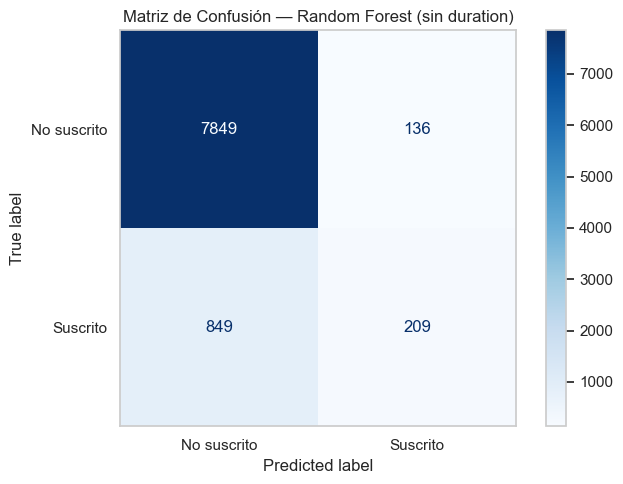

In [10]:
# Entrenamiento
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)

# Reporte de clasificación
print('=' * 55)
print('              REPORTE DE CLASIFICACIÓN')
print('=' * 55)
# LabelEncoder ordena alfabéticamente: no=0, yes=1
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No suscrito', 'Suscrito']
)
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión — Random Forest (sin duration)')
plt.grid(False)
plt.tight_layout()
plt.show()

### Interpretación del inciso a

El modelo presenta un **accuracy elevado** (~90%), lo cual a primera vista nos pareció satisfactorio. Sin embargo, al examinar las métricas por clase observamos un patrón común en datasets desbalanceados:

- **Clase 'no' (no suscrito)**: Precision, recall y F1 altos. El modelo es muy bueno identificando a quienes NO se suscribirán.
- **Clase 'yes' (suscrito)**: Recall significativamente más bajo. El modelo tiene dificultades para identificar correctamente a los clientes que sí se suscribirían (**Falsos Negativos** elevados).

Esto se debe a que ~90% de los registros son de la clase 'no', lo que hace que el modelo tienda a predecir dicha clase en la mayoría de los casos. Es importante notar que al excluir duration, la performance general baja respecto a modelos que la incluyen, pero nuestro modelo es más realista ya que no usa información que no estaría disponible al momento de decidir a quién llamar.

> **Nota**: La variable `duration` fue excluida intencionalmente. Como señalamos en el Ej1 (sección iv), los propios autores advierten que debe descartarse en modelos predictivos reales por representar un caso claro de *data leakage*.

## b) ¿Cuál error es peor?

El objetivo es **incrementar la tasa de suscripción**, entonces...

### Falso Negativo (FN) es el error más crítico.

**Justificación:**

1. Un FN representa a un cliente que tenía el perfil o la intención de suscribirse, pero el modelo lo clasificó como 'no interesado'. Al no contactarlo, el banco pierde directamente un depósito y un cliente potencial.

2. Contactar a un cliente que finalmente no se suscribe (FP) tiene un costo operativo marginal (una llamada telefónica adicional). En cambio, perder un suscriptor potencial implica perder el beneficio financiero completo de ese depósito.

3. Si la prioridad es crecer en captación, es preferible realizar algunas llamadas de más (FP) antes que dejar pasar a quienes efectivamente se habrían suscrito (FN).

4. Como veremos en las secciones siguientes, si el modelo genera más FN para ciertos grupos demográficos (por ejemplo, trabajos históricamente femeninos o ciertos estados civiles), estaría discriminando activamente contra esos grupos, privándolos de ofertas financieras.

---
# Análisis por variable protegida: job como proxy de género

Como establecimos en el Ej1, el dataset no tiene una variable de género. Sin embargo, identificamos que trabajos como `housemaid` y `admin.` fueron históricamente realizados casi exclusivamente por mujeres.

Creamos dos grupos:
- **hist_femenino**: `housemaid`, `admin.`
- **hist_masculino_otro**: todos los demás (`blue-collar`, `technician`, `management`, `services`, `self-employed`, `entrepreneur`, `retired`, `unemployed`, `student`, `unknown`)

Distribución de grupos (job como proxy de género):
job_group
hist_masculino_otro    7786
hist_femenino          1257
Name: count, dtype: int64

--- Performance por grupo (job) ---
hist_femenino: Accuracy=0.8902 | Recall(yes)=0.1849 | Precision(yes)=0.5870 | N=1257
hist_masculino_otro: Accuracy=0.8912 | Recall(yes)=0.1996 | Precision(yes)=0.6087 | N=7786


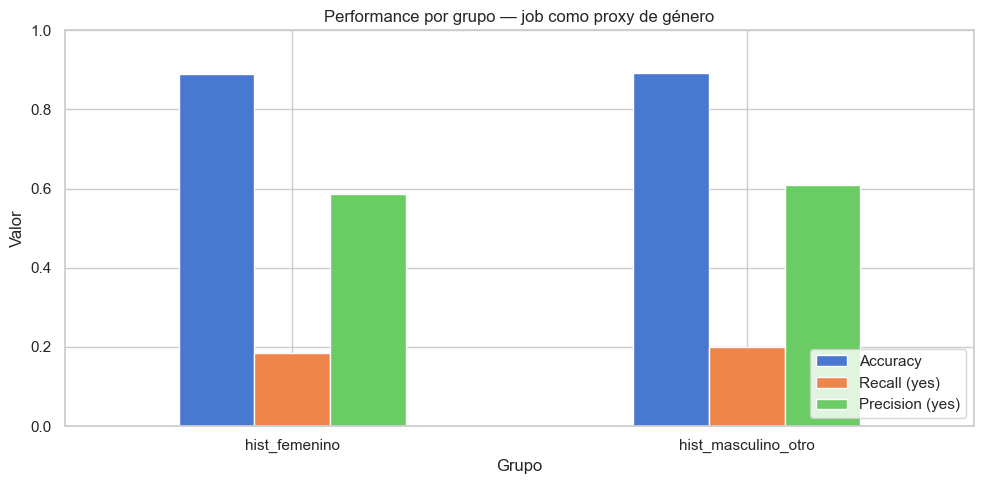

In [11]:
# Construir DataFrame de análisis con valores originales
test_idx = X_test.index
df_analysis = pd.DataFrame({
    'job': df_original.loc[test_idx, 'job'].values,
    'y_true': y_test.values,
    'y_pred': y_pred
})

# Crear proxy de género a partir de job
df_analysis['job_group'] = df_analysis['job'].apply(
    lambda x: 'hist_femenino' if x in ['housemaid', 'admin.'] else 'hist_masculino_otro'
)

print('Distribución de grupos (job como proxy de género):')
print(df_analysis['job_group'].value_counts())
print()

# Métricas por grupo
print('--- Performance por grupo (job) ---')
for grupo in ['hist_femenino', 'hist_masculino_otro']:
    mask = df_analysis['job_group'] == grupo
    yt = df_analysis.loc[mask, 'y_true']
    yp = df_analysis.loc[mask, 'y_pred']
    acc = accuracy_score(yt, yp)
    rec = recall_score(yt, yp, zero_division=0)
    pre = precision_score(yt, yp, zero_division=0)
    print(f'{grupo}: Accuracy={acc:.4f} | Recall(yes)={rec:.4f} | Precision(yes)={pre:.4f} | N={mask.sum()}')

# Visualización
metrics_job = []
for grupo in ['hist_femenino', 'hist_masculino_otro']:
    mask = df_analysis['job_group'] == grupo
    yt = df_analysis.loc[mask, 'y_true']
    yp = df_analysis.loc[mask, 'y_pred']
    metrics_job.append({
        'Grupo': grupo,
        'Accuracy': accuracy_score(yt, yp),
        'Recall (yes)': recall_score(yt, yp, zero_division=0),
        'Precision (yes)': precision_score(yt, yp, zero_division=0)
    })

df_metrics_job = pd.DataFrame(metrics_job).set_index('Grupo')

fig, ax = plt.subplots(figsize=(10, 5))
df_metrics_job.plot(kind='bar', ax=ax)
plt.title('Performance por grupo — job como proxy de género')
plt.ylabel('Valor')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [12]:
diff = abs(metrics_job[0]['Recall (yes)']- metrics_job[1]['Recall (yes)'])

if diff < 0.05:
    print('El modelo es equitativo.')
else:   
     print('El modelo no es equitativo.')
print(f'La diferencia entre los grupos construídos es de {round(diff, 4)}')

El modelo es equitativo.
La diferencia entre los grupos construídos es de 0.0146


### Interpretación de los resultados

Al desglosar la performance por el proxy de género (job_group), podemos observar si el modelo trata de forma diferente a los trabajos históricamente femeninos vs. los demás.

Si el **Recall** de la clase 'yes' difiere significativamente entre grupos, significa que el modelo es mejor detectando potenciales suscriptores en un grupo que en otro. Dado que identificamos al **Falso Negativo como el error más costoso** en el inciso b, una diferencia en Recall entre grupos indicaría que el banco está perdiendo más oportunidades de negocio con un grupo demográfico específico. Dicho esto, el modelo que ignora a potenciales suscriptores a causa de realizar trabajos históricamente femeninizados, fortalece una inequidad histórica.

Sin embargo, como pudimos observar, la diferencia entre los grupos construídos no es mayor a un umbral de 0.05, por lo cual podemos concluir que, en relación a género, el modelo es equitativo.

 